# Forecast Data
## Cleaning

In [121]:
import pandas as pd
import os
from pathlib import Path

FILE_PATH = Path('/Users/kbstudio/Library/CloudStorage/OneDrive-Personal/IECC/Flood Forecast 6 month/202606FloodForecast_6month.xlsx')

OUTPUT_PATH = Path('/Users/kbstudio/Library/CloudStorage/OneDrive-Personal/Project/BAY/data-clean')

forecast = pd.read_excel(FILE_PATH)

print('Total rows:', len(forecast))
print('Rows per month:')
print(forecast['MONTH'].value_counts().sort_index())

month_6 = forecast[forecast['MONTH'] == 6].copy()

print('Month 6 rows:', len(month_6))
month_6.head()



Total rows: 44328
Rows per month:
MONTH
6     7388
7     7388
8     7388
9     7388
10    7388
11    7388
Name: count, dtype: int64
Month 6 rows: 7388


,TAMBON_IDN,TAMBON_T,TAMBON_E,AMPHOE_IDN,AMPHOE_T,AMPHOE_E,PROV_CODE,PROV_T,PROV_E,REGION_CODE,REGION,TYPE_T,TYPE_E,YEAR,MONTH
0,100101,แขวงพระบรมมหาราช,Phraborom Maharatchawang,1001,เขตพระนคร,Phra Nakhon District,10,กรุงเทพมหานคร,Bangkok,3,กลาง,ไม่มีน้ำท่วม,norisk,2026,6
1,100102,แขวงวังบูรพาภิรม,Wang Burapha Phirom,1001,เขตพระนคร,Phra Nakhon District,10,กรุงเทพมหานคร,Bangkok,3,กลาง,ไม่มีน้ำท่วม,norisk,2026,6
2,100103,แขวงวัดราชบพิธ,Wat Ratchabophit,1001,เขตพระนคร,Phra Nakhon District,10,กรุงเทพมหานคร,Bangkok,3,กลาง,ไม่มีน้ำท่วม,norisk,2026,6
3,100104,แขวงสำราญราษฎร์,Samran Rat,1001,เขตพระนคร,Phra Nakhon District,10,กรุงเทพมหานคร,Bangkok,3,กลาง,ไม่มีน้ำท่วม,norisk,2026,6
4,100105,แขวงศาลเจ้าพ่อเส,San Chaopho Suea,1001,เขตพระนคร,Phra Nakhon District,10,กรุงเทพมหานคร,Bangkok,3,กลาง,ไม่มีน้ำท่วม,norisk,2026,6


In [122]:
output_file = OUTPUT_PATH / '202606_month6.xlsx'
month_6.to_excel(output_file, index=False)

print('Saved', len(month_6), 'rows to', output_file)

Saved 7388 rows to /Users/kbstudio/Library/CloudStorage/OneDrive-Personal/Project/BAY/data-clean/202606_month6.xlsx


## Shape Files

In [123]:
import geopandas as gpd

SHAPE_PATH = Path('/Users/kbstudio/Library/CloudStorage/OneDrive-Personal/IECC/TH_TAMBON_json/tha_admbnda_adm3_rtsd_20220121_geo.json')

shapes = gpd.read_file(SHAPE_PATH)

print('ADM3 count:', shapes['ADM3_PCODE'].nunique())

shapes[['ADM3_PCODE', 'ADM3_EN', 'ADM2_EN', 'ADM1_EN']].head()

ADM3 count: 7425


,ADM3_PCODE,ADM3_EN,ADM2_EN,ADM1_EN
0,TH100101,Phraborom Maharatchawang,Phra Nakhon,Bangkok
1,TH100102,Wang Burapha Phirom,Phra Nakhon,Bangkok
2,TH100103,Wat Ratchabophit,Phra Nakhon,Bangkok
3,TH100104,Samran Rat,Phra Nakhon,Bangkok
4,TH100105,San Chaopho Suea,Phra Nakhon,Bangkok


(np.float64(96.92890833810007),
 np.float64(106.05163385990006),
 np.float64(4.870453668800053),
 np.float64(21.20730616120005))

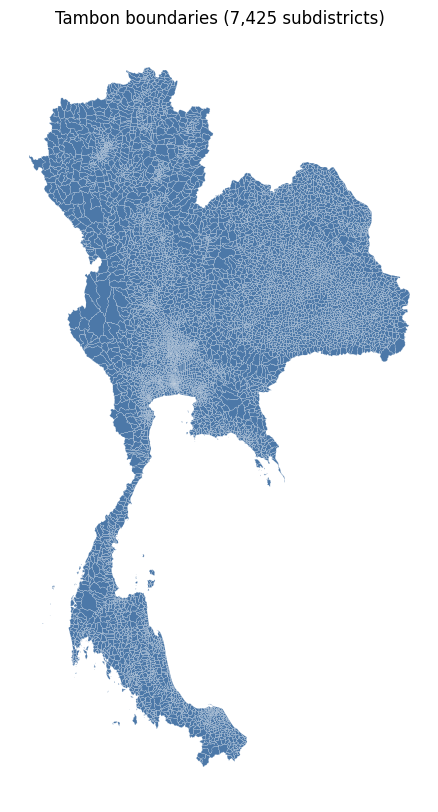

In [134]:
ax = shapes.plot(figsize=(8, 10), color='#4C78A8', edgecolor='white', linewidth=0.1)
ax.set_title(f'Tambon boundaries ({len(shapes):,} subdistricts)')
ax.axis('off')

## Join

In [125]:
month_6['CODE'] = month_6['TAMBON_IDN'].astype(str)
shapes['CODE'] = shapes['ADM3_PCODE'].str.removeprefix('TH')

forecast_codes = set(month_6['CODE'])
shape_codes = set(shapes['CODE'])

matched = forecast_codes & shape_codes
only_in_forecast = forecast_codes - shape_codes
only_in_shapes = shape_codes - forecast_codes

print('Matched geocodes:  ', len(matched))
print('Only in forecast:  ', len(only_in_forecast))
print('Only in shapes:    ', len(only_in_shapes))

print('\nMismatch — in forecast but missing from shapes:')
print(sorted(only_in_forecast))

print('\nMismatch — in shapes but missing from forecast:')
print(sorted(only_in_shapes))

Matched geocodes:   7381
Only in forecast:   6
Only in shapes:     44

Mismatch — in forecast but missing from shapes:
['201201', '401050', '530407', '630191', '810150', '860805']

Mismatch — in shapes but missing from forecast:
['102704', '102705', '102902', '103604', '103605', '104302', '104502', '104503', '104504', '160510', '160619', '160620', '190509', '190909', '200622', '210104', '210113', '230101', '250110', '300101', '300113', '301811', '302401', '330102', '340101', '410111', '480102', '520101', '520102', '520103', '520104', '530306', '570121', '630101', '630102', '630103', '630104', '660501', '670301', '710101', '710102', '801201', '810101', '810102']


## Fix Mismatch

In [126]:
def nearest_shape_code(forecast_row):
    amphoe = forecast_row['AMPHOE_E'].replace(' District', '').strip()
    same_amphoe = shapes.loc[shapes['ADM2_EN'].str.lower() == amphoe.lower(), 'CODE']
    target_last2 = int(forecast_row['CODE'][-2:])
    return min(same_amphoe, key=lambda code: abs(int(code[-2:]) - target_last2))

orphans = month_6[month_6['CODE'].isin(only_in_forecast)]
remap = {row['CODE']: nearest_shape_code(row) for _, row in orphans.iterrows()}

print('Re-mapped orphan forecast codes to the nearest shape:')
for old, new in remap.items():
    print(f'  {old} -> {new}')

month_6['CODE'] = month_6['CODE'].replace(remap)
month_6['TAMBON_IDN'] = month_6['CODE'].astype(int)

Re-mapped orphan forecast codes to the nearest shape:
  201201 -> 200401
  401050 -> 401017
  530407 -> 530406
  630191 -> 630115
  810150 -> 810118
  860805 -> 860804


In [127]:
region_by_prov = (month_6[['PROV_CODE', 'REGION_CODE', 'REGION']]
                  .drop_duplicates('PROV_CODE')
                  .set_index('PROV_CODE'))

missing = shapes[shapes['CODE'].isin(only_in_shapes)].reset_index(drop=True)

norisk_rows = pd.DataFrame({
    'TAMBON_IDN': missing['CODE'].astype(int),
    'TAMBON_T':   missing['ADM3_TH'],
    'TAMBON_E':   missing['ADM3_EN'],
    'AMPHOE_IDN': missing['ADM2_PCODE'].str.removeprefix('TH').astype(int),
    'AMPHOE_T':   missing['ADM2_TH'],
    'AMPHOE_E':   missing['ADM2_EN'],
    'PROV_CODE':  missing['ADM1_PCODE'].str.removeprefix('TH').astype(int),
    'PROV_T':     missing['ADM1_TH'],
    'PROV_E':     missing['ADM1_EN'],
    'TYPE_T':     'ไม่มีน้ำท่วม',
    'TYPE_E':     'norisk',
    'YEAR':       2026,
    'MONTH':      6,
    'CODE':       missing['CODE'],
})
norisk_rows['REGION_CODE'] = norisk_rows['PROV_CODE'].map(region_by_prov['REGION_CODE'])
norisk_rows['REGION']      = norisk_rows['PROV_CODE'].map(region_by_prov['REGION'])

print('Added', len(norisk_rows), 'norisk rows from shapes with no forecast.')
norisk_rows[['TAMBON_IDN', 'TAMBON_E', 'AMPHOE_E', 'PROV_E', 'REGION', 'TYPE_E']].head()

Added 44 norisk rows from shapes with no forecast.


,TAMBON_IDN,TAMBON_E,AMPHOE_E,PROV_E,REGION,TYPE_E
0,102704,Nawamin,Bueng Kum,Bangkok,กลาง,norisk
1,102705,Nuan Chan,Bueng Kum,Bangkok,กลาง,norisk
2,102902,Wong Sawang,Bang Sue,Bangkok,กลาง,norisk
3,103604,Don Mueang,Don Mueang,Bangkok,กลาง,norisk
4,103605,Sanam Bin,Don Mueang,Bangkok,กลาง,norisk


## Output
- output as excel
- format TAMBON_IDN, AMPHOE_IDN, PROV_CODE ให้มี prefix TH สำหรับไป join ใน tableau ง่ายๆ

In [128]:
month_6_full = pd.concat([month_6, norisk_rows], ignore_index=True)

severity = {'norisk': 0, 'flood risk': 1, 'flashflood': 2}
month_6_full = (month_6_full
                .sort_values('TYPE_E', key=lambda s: s.map(severity))
                .drop_duplicates('CODE', keep='last')
                .sort_values('CODE')
                .reset_index(drop=True))

month_6_full['TAMBON_IDN'] = 'TH' + month_6_full['TAMBON_IDN'].astype(str).str.zfill(6)
month_6_full['AMPHOE_IDN'] = 'TH' + month_6_full['AMPHOE_IDN'].astype(str).str.zfill(4)
month_6_full['PROV_CODE'] = 'TH' + month_6_full['PROV_CODE'].astype(str).str.zfill(2)

output_file = OUTPUT_PATH / '202606_month6_full.xlsx'
month_6_full.drop(columns='CODE').to_excel(output_file, index=False)

print('Saved', len(month_6_full), 'rows to', output_file)
print('Unique TAMBON_IDN:', month_6_full['TAMBON_IDN'].nunique())

Saved 7425 rows to /Users/kbstudio/Library/CloudStorage/OneDrive-Personal/Project/BAY/data-clean/202606_month6_full.xlsx
Unique TAMBON_IDN: 7425


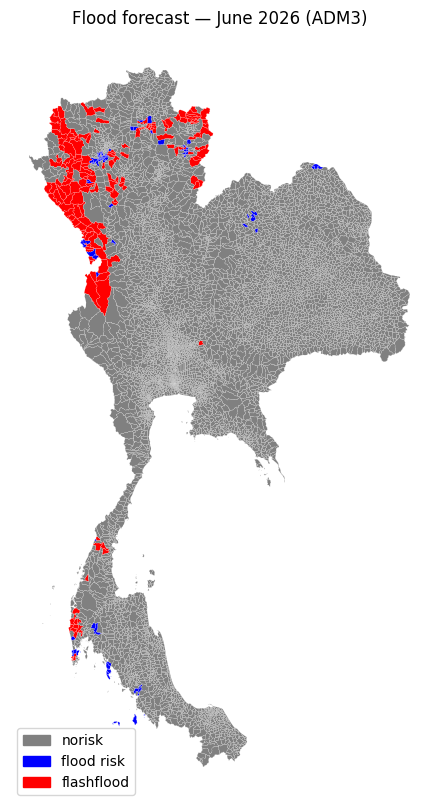

In [129]:
RISK_COLORS = {'norisk': 'grey', 'flood risk': 'blue', 'flashflood': 'red'}

severity = {'norisk': 0, 'flood risk': 1, 'flashflood': 2}
risk_per_code = (month_6_full
                 .sort_values('TYPE_E', key=lambda s: s.map(severity))
                 .drop_duplicates('CODE', keep='last')
                 .set_index('CODE')['TYPE_E'])

risk_map = shapes.copy()
risk_map['TYPE_E'] = risk_map['CODE'].map(risk_per_code).fillna('norisk')

ax = risk_map.plot(color=risk_map['TYPE_E'].map(RISK_COLORS),
                   figsize=(8, 10), edgecolor='white', linewidth=0.1)
ax.set_title('Flood forecast — June 2026 (ADM3)')
ax.axis('off')

from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=c, label=t) for t, c in RISK_COLORS.items()], loc='lower left')

## Recheck
- เช็ค excel ที่ output ออกไป เพราะใน tableau เจอ null

In [130]:
RECHECK = Path('/Users/kbstudio/Library/CloudStorage/OneDrive-Personal/Project/BAY/data-clean/202606_month6_full.xlsx')

forecast_recheck = pd.read_excel(RECHECK)

null_rows = forecast_recheck[forecast_recheck['TYPE_E'].isnull()].copy()
print('Rows with null:', len(null_rows))

null_rows[['TAMBON_IDN', 'TAMBON_E', 'AMPHOE_E', 'PROV_E', 'REGION', 'TYPE_E']].head()

Rows with null: 0


,TAMBON_IDN,TAMBON_E,AMPHOE_E,PROV_E,REGION,TYPE_E


In [131]:
no_risk = forecast_recheck[forecast_recheck['TYPE_E'] == 'norisk'].copy()
print('Rows with norisk:', len(no_risk))

flood_risk = forecast_recheck[forecast_recheck['TYPE_E'] == 'flood risk'].copy()
print('Rows with flood risk:', len(flood_risk))

flashflood = forecast_recheck[forecast_recheck['TYPE_E'] == 'flashflood'].copy()
print('Rows with flashflood:', len(flashflood))

print('All risk:', len(no_risk) + len(flood_risk) + len(flashflood))

counts = forecast_recheck['TYPE_E'].value_counts()
print('Counts by TYPE_E:', len(counts))

Rows with norisk: 7162
Rows with flood risk: 90
Rows with flashflood: 173
All risk: 7425
Counts by TYPE_E: 3


- ลองเช็คคู่กับ shapefiles อีกรอบ

In [132]:
forecast_recheck['CODE'] = forecast_recheck['TAMBON_IDN'].str.removeprefix('TH')
forecast_recheck_codes = set(forecast_recheck['CODE'])

matched_c = forecast_recheck_codes & shape_codes
only_in_forecast_c = forecast_recheck_codes - shape_codes
only_in_shapes_c = shape_codes - forecast_recheck_codes

print('Matched geocodes:  ', len(matched_c))
print('Only in forecast:  ', len(only_in_forecast_c))
print('Only in shapes:    ', len(only_in_shapes_c))

print('\nMismatch — in forecast but missing from shapes:')
print(sorted(only_in_forecast_c))

print('\nMismatch — in shapes but missing from forecast:')
print(sorted(only_in_shapes_c))




Matched geocodes:   7425
Only in forecast:   0
Only in shapes:     0

Mismatch — in forecast but missing from shapes:
[]

Mismatch — in shapes but missing from forecast:
[]


## Output geojson
- ตอนแรก output แค่ excel แต่พอ join excel&geojson in tableau มี null
- ใช้ python ดูกี่รอบก็ไม่มี เลย output geojson เลยละกัน
- สรุป tableau เอ๋อไรไม่รู้ แต่ไม่มี null แล้ว

In [133]:
risk_by_code = month_6_full.set_index('CODE')[['TYPE_E', 'TYPE_T']]

shapes_risk = shapes.merge(risk_by_code, left_on='CODE', right_index=True, how='left')
shapes_risk = shapes_risk[[
    'ADM3_PCODE', 'ADM3_EN', 'ADM3_TH',
    'ADM2_EN', 'ADM1_EN',
    'TYPE_E', 'TYPE_T', 'geometry',
]]

geojson_file = OUTPUT_PATH / '202606_month6_risk.geojson'
shapes_risk.to_file(geojson_file, driver='GeoJSON')

print('Saved', len(shapes_risk), 'features to', geojson_file)
print('Null TYPE_E:', shapes_risk['TYPE_E'].isnull().sum())

Saved 7425 features to /Users/kbstudio/Library/CloudStorage/OneDrive-Personal/Project/BAY/data-clean/202606_month6_risk.geojson
Null TYPE_E: 0
